### Set up

In [15]:
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics
import torch.nn.functional as F

In [16]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load dataset

In [17]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [18]:
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [19]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [20]:
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)

### Model - Image Classifier

In [21]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
                                 nn.Linear(n_hidden1, n_hidden2), nn.ReLU(), nn.Linear(n_hidden2, n_classes))

    def forward(self, X):
        return self.mlp(X)

In [22]:
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs = 100

In [23]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [24]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

In [25]:
params_to_regularize = [param for name, param in model.named_parameters() if not "bias" in name and not "bn" in name]
params_to_regularize

[Parameter containing:
 tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
         [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
         [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
         ...,
         [-0.0283,  0.0160, -0.0331,  ..., -0.0214, -0.0285,  0.0025],
         [ 0.0149, -0.0222,  0.0158,  ...,  0.0002,  0.0009,  0.0010],
         [ 0.0060, -0.0062, -0.0113,  ...,  0.0222,  0.0135, -0.0049]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([[-0.0405, -0.0364,  0.0101,  ...,  0.0220, -0.0230, -0.0297],
         [ 0.0192, -0.0256, -0.0146,  ...,  0.0551, -0.0566, -0.0176],
         [ 0.0495,  0.0210, -0.0055,  ..., -0.0085,  0.0442, -0.0555],
         ...,
         [ 0.0373, -0.0126,  0.0311,  ...,  0.0135, -0.0339, -0.0570],
         [-0.0412, -0.0158,  0.0039,  ..., -0.0468,  0.0320, -0.0021],
         [ 0.0191, -0.0063, -0.0476,  ...,  0.0409, -0.0018,  0.0374]],
        device='cuda:0', r

In [26]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs, verbose=1):
    model.train()
    losses = []
    val_losses = []
    accuracies = []
    val_accuracies = []
    for epoch in range(n_epochs):
        total_loss = 0.
        total_acc = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            main_loss = criterion(y_pred, y_batch)
            l1_loss = sum(param.abs().sum() for param in params_to_regularize) # l1
            loss = main_loss + 1e-4 * l1_loss # l1 regularizer
            total_loss += loss.item()
            total_acc += accuracy(y_pred, y_batch).item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        train_accuracy = total_acc / len(train_loader)
        x_val, y_val = next(iter(valid_loader))
        y_val_pred = model(x_val.to(device))
        val_loss = criterion(y_val_pred, y_val.to(device))
        val_acc = accuracy(y_val_pred, y_val.to(device)).item()
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        accuracies.append(train_accuracy)
        val_accuracies.append(val_acc)
        if verbose:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}, Train Accuracy:         {train_accuracy}, Validation Accuracy: {val_acc}")
    return losses, val_losses, accuracies, val_accuracies

In [27]:
train_loss, val_loss, train_acc, val_acc = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs)

Epoch 1/100, Loss: 1.8943, Validation Loss: 0.9158344268798828, Train Accuracy:         0.5702021424160447, Validation Accuracy: 0.609375
Epoch 2/100, Loss: 1.2241, Validation Loss: 0.7336630821228027, Train Accuracy:         0.7299176357513251, Validation Accuracy: 0.7421875
Epoch 3/100, Loss: 1.0908, Validation Loss: 0.715989351272583, Train Accuracy:         0.7832788276117901, Validation Accuracy: 0.74609375
Epoch 4/100, Loss: 1.0047, Validation Loss: 0.7144317626953125, Train Accuracy:         0.8066153908884802, Validation Accuracy: 0.78515625
Epoch 5/100, Loss: 0.9519, Validation Loss: 0.6579645872116089, Train Accuracy:         0.8170737779417704, Validation Accuracy: 0.78515625
Epoch 6/100, Loss: 0.9075, Validation Loss: 0.6075719594955444, Train Accuracy:         0.825526216695475, Validation Accuracy: 0.80859375
Epoch 7/100, Loss: 0.8738, Validation Loss: 0.5558967590332031, Train Accuracy:         0.832029231204543, Validation Accuracy: 0.81640625
Epoch 8/100, Loss: 0.8399,

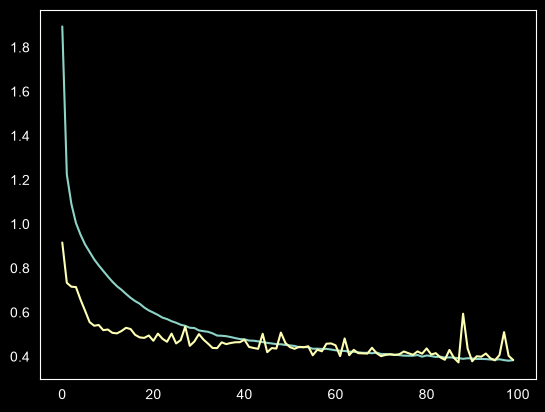

In [28]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()